    populasi_ha  sex_ratio  yield_kg_ha
0           124       0.64    63.734000
1           124       0.70    68.996800
2           124       0.70    70.432000
3           124       0.66    65.545600
4           124       0.63    62.500400
..          ...        ...          ...
67          142       0.66    74.862692
68          142       0.66    74.919231
69          142       0.64    73.216154
70          142       0.72    82.283077
71          142       0.71    80.700000

[72 rows x 3 columns]
0     63.734000
1     68.996800
2     70.432000
3     65.545600
4     62.500400
        ...    
67    74.862692
68    74.919231
69    73.216154
70    82.283077
71    80.700000
Name: yield_kg_ha, Length: 72, dtype: float64
              umur_tanaman  populasi_ha  curah_hujan  sex_ratio  yield_kg_ha
umur_tanaman      1.000000     0.450864     0.040620  -0.131123     0.169735
populasi_ha       0.450864     1.000000     0.017898  -0.035236     0.587736
curah_hujan       0.040620     0.017898     

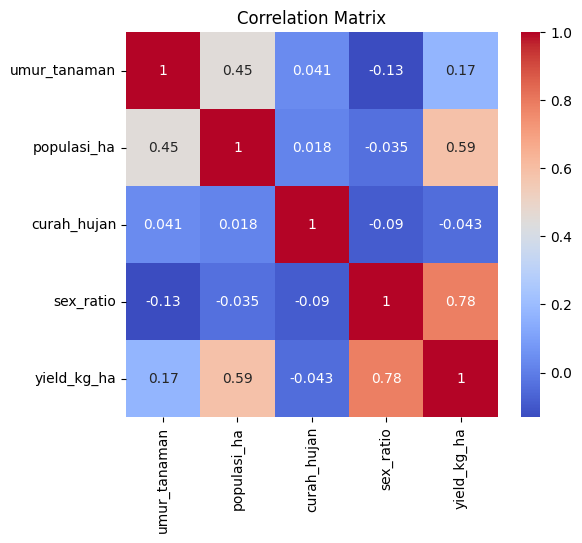

Correlation_Sr: 0.7843816091328842
P-value_Sr: 3.6365598351386687e-16
Correlation_Ph: 0.587736205580993
P-value_ph: 5.7049674054809345e-08
      Variable  Coefficient
0  populasi_ha     0.555387
1    sex_ratio   110.837765
[61.97104121 74.18476259 64.75516529 63.07941886 76.9569049  73.06679952
 65.29617417 75.84852725 63.64678763 76.39193248]
MSE: 0.4534353147272444
R²: 0.9907786859856074


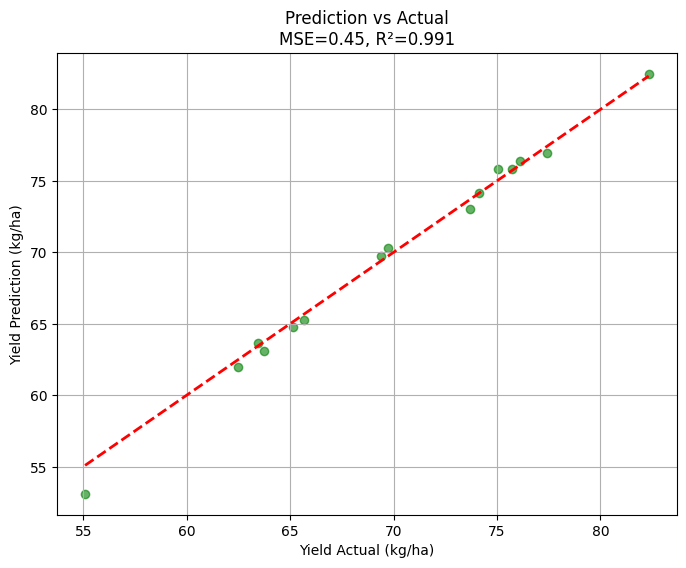

Yield Prediction: [80.28203786]
   kode_blok  cluster
0        A01        2
1        A01        2
2        A01        2
3        A01        2
4        A01        2
..       ...      ...
67       C02        0
68       C02        0
69       C02        0
70       C02        1
71       C02        1

[72 rows x 2 columns]


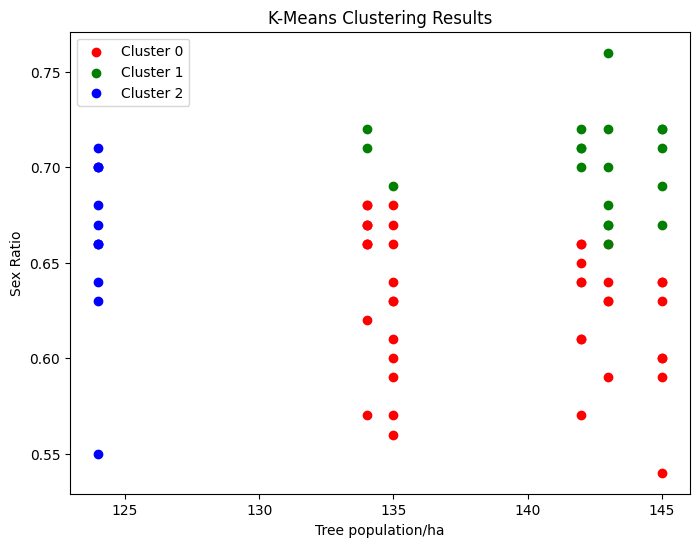

   populasi_ha  sex_ratio  yield_prediction
0          100       0.10        -10.102263
1          100       0.15         -4.560374
2          100       0.20          0.981514
3          100       0.25          6.523402
4          100       0.30         12.065291


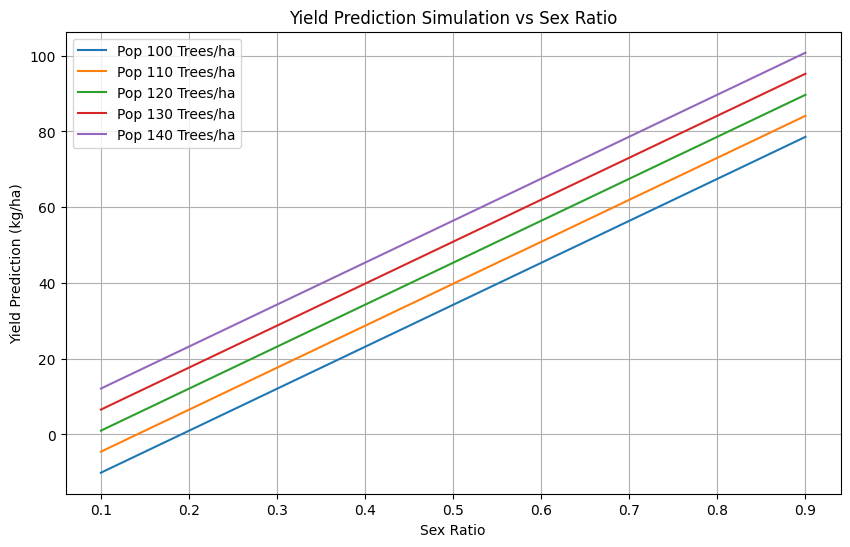

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("datasetKS2.csv")
df['yield_kg_ha'] = df['produksi'] / df['luas_ha']
subset = df[[
    'populasi_ha',
    'sex_ratio',
    'yield_kg_ha'
]]
print(subset)
print(df['yield_kg_ha'])

corr_matrix = df[['umur_tanaman','populasi_ha','curah_hujan','sex_ratio','yield_kg_ha']].corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

corr, p_value = pearsonr(df['sex_ratio'], df['yield_kg_ha'])
print("Correlation_Sr:", corr)
print("P-value_Sr:", p_value)
corr, p_value = pearsonr(df['populasi_ha'], df['yield_kg_ha'])
print("Correlation_Ph:", corr)
print("P-value_ph:", p_value)

X = df[['populasi_ha','sex_ratio']]
y = df['yield_kg_ha']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)

coeff = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})
print(coeff)

y_pred = model.predict(X_test)
print(y_pred[:10])

from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', lw=2)  # garis ideal
plt.xlabel('Yield Actual (kg/ha)')
plt.ylabel('Yield Prediction (kg/ha)')
plt.title(f'Prediction vs Actual\nMSE={mse:.2f}, R²={r2:.3f}')
plt.grid(True)
plt.show()

data_baru = pd.DataFrame({
    'populasi_ha':[143],
    'sex_ratio':[0.70]
})
prediksi = model.predict(data_baru)
print("Yield Prediction:", prediksi)

features = df[[
    'populasi_ha',
    'sex_ratio',
    'yield_kg_ha'
]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=3, 
    random_state=42
)
df['cluster'] = kmeans.fit_predict(scaled_data)
print(df[['kode_blok','cluster']])

import matplotlib.patches as mpatches

colors = ['red','green','blue']
labels = ['Cluster 0','Cluster 1','Cluster 2']

plt.figure(figsize=(8,6))
for i, color in enumerate(colors):
    plt.scatter(
        X['populasi_ha'][df['cluster']==i],
        X['sex_ratio'][df['cluster']==i],
        c=color,
        label=labels[i]
    )

plt.xlabel('Tree population/ha')
plt.ylabel('Sex Ratio')
plt.title('K-Means Clustering Results')
plt.legend()
plt.show()

# Range simulasi
populasi_range = np.arange(100, 141, 5)      # 100 sampai 140
sex_ratio_range = np.arange(0.1, 0.91, 0.05) # 0.1 sampai 0.9

# Buat grid semua kombinasi
simulasi_list = []
for p in populasi_range:
    for sr in sex_ratio_range:
        simulasi_list.append({'populasi_ha': p, 'sex_ratio': sr})

data_simulasi = pd.DataFrame(simulasi_list)

# Prediksi yield
data_simulasi['yield_prediction'] = model.predict(data_simulasi)
print(data_simulasi.head())

plt.figure(figsize=(10,6))

for p in [100, 110, 120, 130, 140]:
    subset = data_simulasi[data_simulasi['populasi_ha'] == p]
    plt.plot(subset['sex_ratio'], subset['yield_prediction'], label=f'Pop {p} Trees/ha')

plt.xlabel('Sex Ratio')
plt.ylabel('Yield Prediction (kg/ha)')
plt.title('Yield Prediction Simulation vs Sex Ratio')
plt.legend()
plt.grid(True)
plt.show()